<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #8b5cf6; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Retropropagación, Optimizadores y Regularización L2 🔄📉
      </h1>
      <p style="margin: 6px 0 0 0; color: #8b5cf6; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Backprop, Adam & Weight Decay
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #8b5cf6; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/03_Retropropagacion_Optimizadores_y_Regularizacion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Problema del Aprendizaje: ¿De Dónde Salen los Pesos? 🔄

El Cuaderno **02** de este módulo calculó la propagación hacia adelante (*forward pass*) con pesos **fijos** — elegidos a mano o generados al azar. Ese cuaderno dejó una pregunta sin responder: en un modelo entrenado de verdad, como el `MLPClassifier` que alcanzó 98.61% de exactitud sobre `sensores_maquinaria.csv`, ¿de dónde salieron esos pesos? La respuesta es **retropropagación** (*backpropagation*), combinada con **descenso de gradiente**.

**La intuición, en tres pasos:**

1. **Propagación hacia adelante:** con los pesos actuales (al principio, aleatorios), la red produce una predicción $\hat{y}$. Se compara contra el valor real $y$ mediante una **función de pérdida** $L(\hat{y}, y)$ — un número que mide qué tan mal lo hizo la red en ese ejemplo.
2. **Propagación hacia atrás (retropropagación):** se necesita saber cuánto *cada peso individual* de *cada capa* contribuyó a ese error, para poder corregirlo. La **regla de la cadena** del cálculo diferencial permite calcular esto de forma sistemática: el gradiente de la pérdida respecto a los pesos de la última capa se calcula primero (es el más directo), y ese resultado se reutiliza para calcular el gradiente de la capa anterior, y así sucesivamente hacia atrás, capa por capa, hasta llegar a la primera. De ahí el nombre: el error calculado en la salida se "propaga hacia atrás" a través de la red.
3. **Actualización de pesos (descenso de gradiente):** una vez que se conoce el gradiente $\frac{\partial L}{\partial w}$ de la pérdida respecto a cada peso $w$, se actualiza cada peso dando un pequeño paso en la dirección **opuesta** al gradiente (el gradiente apunta hacia donde la pérdida *aumenta*, así que se resta):

$$w \leftarrow w - \eta \, \frac{\partial L}{\partial w}$$

donde $\eta$ (eta) es la **tasa de aprendizaje** (*learning rate*), que controla el tamaño del paso. Este ciclo completo — hacia adelante, hacia atrás, actualizar — se repite miles de veces (una "época" es una pasada completa por todos los datos de entrenamiento), y es exactamente lo que hace `MLPClassifier.fit()` internamente cuando se llamó en el Cuaderno 02. No hace falta dominar el cálculo multivariable completo para seguir el resto de este cuaderno, pero sí es importante entender el mecanismo: **la regla de la cadena permite repartir la "culpa" del error entre todos los pesos de la red, capa por capa, desde la salida hacia la entrada.**

---
## 2. Un Ejemplo Numérico Mínimo: Un Solo Peso, un Solo Paso 🔢

Para ver la regla de la cadena en acción sin la complejidad de una red completa, se reduce el problema a su mínima expresión: **una sola entrada $x$, un solo peso $w$, un solo sesgo $b$**, activación sigmoide, y pérdida de error cuadrático medio $L = \frac{1}{2}(a - y)^2$ (el factor $\frac{1}{2}$ es solo una convención que simplifica la derivada). El objetivo: calcular a mano el gradiente $\frac{\partial L}{\partial w}$ y dar **un** paso de descenso de gradiente, verificando que la pérdida efectivamente baja.

La regla de la cadena descompone $\frac{\partial L}{\partial w}$ en tres factores, cada uno fácil de derivar por separado:

$$\frac{\partial L}{\partial w} = \underbrace{\frac{\partial L}{\partial a}}_{\text{cuanto cambia } L \text{ si cambia } a} \cdot \underbrace{\frac{\partial a}{\partial z}}_{\text{cuanto cambia } a \text{ si cambia } z} \cdot \underbrace{\frac{\partial z}{\partial w}}_{\text{cuanto cambia } z \text{ si cambia } w}$$

Con $z = wx + b$, $a = \sigma(z)$, $L = \frac{1}{2}(a-y)^2$, cada factor tiene una forma cerrada conocida: $\frac{\partial L}{\partial a} = (a - y)$, $\frac{\partial a}{\partial z} = \sigma(z)\big(1-\sigma(z)\big)$ (la derivada de la sigmoide, expresada en términos de sí misma), y $\frac{\partial z}{\partial w} = x$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Red minima: 1 entrada, 1 peso, 1 sesgo
x = 2.0
y = 1.0        # valor real (objetivo)
w = 0.5        # peso inicial
b = 0.0        # sesgo inicial
lr = 0.1       # tasa de aprendizaje

# --- 1. Hacia adelante ---
z = w * x + b
a = sigmoid(z)
L = 0.5 * (a - y) ** 2
print(f"Hacia adelante:  z = {z:.4f}   a = sigmoide(z) = {a:.4f}   L = {L:.4f}")

# --- 2. Hacia atras: regla de la cadena, termino por termino ---
dL_da = (a - y)
da_dz = a * (1 - a)
dz_dw = x
dz_db = 1.0

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print(f"\nHacia atras (regla de la cadena):")
print(f"  dL/da = (a - y)          = {dL_da:.4f}")
print(f"  da/dz = a*(1-a)          = {da_dz:.4f}")
print(f"  dz/dw = x                = {dz_dw:.4f}")
print(f"  dL/dw = dL/da * da/dz * dz/dw = {dL_dw:.4f}")
print(f"  dL/db = dL/da * da/dz * dz/db = {dL_db:.4f}")

# --- 3. Actualizacion de pesos (un paso de descenso de gradiente) ---
w_nuevo = w - lr * dL_dw
b_nuevo = b - lr * dL_db
print(f"\nActualizacion:  w: {w:.4f} -> {w_nuevo:.4f}    b: {b:.4f} -> {b_nuevo:.4f}")

# Verificacion: la perdida debe bajar con los pesos nuevos
z2 = w_nuevo * x + b_nuevo
a2 = sigmoid(z2)
L2 = 0.5 * (a2 - y) ** 2
print(f"\nPerdida ANTES del paso: {L:.4f}")
print(f"Perdida DESPUES del paso: {L2:.4f}")
print(f"La perdida bajo: {L2 < L}")

Hacia adelante:  z = 1.0000   a = sigmoide(z) = 0.7311   L = 0.0362

Hacia atras (regla de la cadena):
  dL/da = (a - y)          = -0.2689
  da/dz = a*(1-a)          = 0.1966
  dz/dw = x                = 2.0000
  dL/dw = dL/da * da/dz * dz/dw = -0.1058
  dL/db = dL/da * da/dz * dz/db = -0.0529

Actualizacion:  w: 0.5000 -> 0.5106    b: 0.0000 -> 0.0053

Perdida ANTES del paso: 0.0362
Perdida DESPUES del paso: 0.0348
La perdida bajo: True


**Lectura:** antes de actualizar, $z=1.0$, $a=0.7311$ y la pérdida es $L=0.0362$ (la red predice 0.73 cuando el valor real es 1.0). La regla de la cadena da $\frac{\partial L}{\partial w}=-0.1058$ y $\frac{\partial L}{\partial b}=-0.0529$ — ambos gradientes son **negativos**, lo que significa que aumentar $w$ y $b$ reduciría la pérdida. El paso de descenso de gradiente hace justamente eso: $w$ sube de 0.5 a 0.5106 y $b$ sube de 0.0 a 0.0053. Tras el paso, la nueva pérdida es $L=0.0348$, efectivamente **menor** que la original (0.0362) — un solo paso diminuto, pero en la dirección correcta. Esto es, en esencia, exactamente lo que hace `MLPClassifier.fit()` miles de veces, con miles de pesos organizados en matrices en lugar de uno solo, y con la regla de la cadena aplicada capa por capa hacia atrás en vez de un solo salto directo.

---
## 3. Los Datos: Diagnóstico Celular 🔬

El resto de este cuaderno usa `diagnostico_celular.csv` (ya presentado en el Cuaderno 02): 569 muestras con 8 mediciones geométricas del núcleo celular y una variable objetivo binaria `diagnostico`.

In [2]:
import pandas as pd
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_segmentacion_compleja.csv": "...",
    "diagnostico_celular.csv": "H4sIAChomWoC/219244tO27k+wD+k0JBoqjb1xgNuzHwg91Guz2Yzx8yIqi1tjEPveuc0zsrMyWKDAaDzL//5V//7W///O9/jT9//vHX//uP//77X/Bvf/n5z7/+/d/+/a//+Hv9v3/5+1/r//qv//7L//m3f/3Lv+pf/+Vv//6ff/mXP/7Df/zLH3/jP//7P/7xt//6Z/73+Af8xv/6if/rf//H3/7rH//2L3/7p//V9++9P739jvPTzX7jz9b6b/tpv70fjx+294ofI/5z/kff8eOf/pe137l/4uodfw77vfnnwnXt+M4L2z4LP8+6+NfWd17a72/8B+u/NuOi+D/ixm3wlu3mvfq8eUW/+D3d9sV1/dftx/Coe//O8zPO+uVDxa+KJz0jLzPvuKxN05NaPJ3/Do/bzbig2926XRv5Y9jB7fBn84G72a/H883f/XMs39Xjnp2Pg7+38aD453ba4SMevNT9jV/V8z1jNb1xVa6vwVfE2trGmjguG7+xqvGgZ/zceNyfGffiXzv4sXziV4yVy9PmPVPXtVzIYz8nFuRnxi0PHxG3usPyx5mXV8/3ZuvH/Lf5zxm/N19t1u3y99vALhh/SztTKxLbG+s/YoHjtSwWZsc68v2t4cHW4lYPu/w5jJfGMp60lpO2NmJd9ulals1FvYZ/u9P5i/IXwlZioeNZD6wsbtxt1IWwTp/5BHH/iRfoR/eLFYq/eSfuF4968oFhnLTj1nTDgTeYY72tGD9xEFb/ufmgscO/WMw+Ohbl5r9ZN228cSf8Nx7cdv55V/6KNQ/3osMow6TxgGvwLNTt/Hed3PkeO++/8UrrxK/Ck51FEzFegOvDpufVZsQlceHKE3vCMvetG24siGHvN380O1rO0/Pt+uforbLPM7gwsMw45zQav0frEq+Wp2ilrYUBzbWwMLER/KsnNlFGgD302OOfTis9OEn958zfOAXTms7fnjRX/P25sKaj47L7O8NA01hjUVqe3rBHmmkzGonTaOxOWJ+18FQduz/wrLZgqPNnN/+lT9jcvQF/0fbmC0wYW5ykvtJq8r5jxznsHhfq9NJHaFnjGnq2YdqNsL+4Pr1oz5e7ceHiQaeHmvQXxr2VJwyPErdasOt0nrfTSusg2uYPLGyH5dLWTt4sjnMcQO8/y51b33B64uLz8Yrt7DPknBa8TLqotIFYnPtej8sD/9KdNrpH12EKS5sRCLCa/rNxEvOvHyzGwmL0degu9ux6uYwQM2w23m7m280JDxqm5nzLyfU/MIO273wPijumIfDst3NkMYtveGDko2NhzF0BIiJWXL0zPsQ59fC93AQ63dnxb9Z55PsxPSj9Gpx2hsBzr84838zpD50+39rQWYoViZgX7xIWnBGwL6vlpJPZfL7F99zzjs/ZTW+Yb5ah6LS0NgQfPCccdhgpw+ieZWThH3LfL4wsTtO68hULtxsD7zcc77eanKHnjsd14UnSpYVvGuVDjykmwWC4nC1uX2c+XjXWM8LugUecsUr0e5ebPTYjks2loxi/sOOeEQHSaGLX03MseaeIQti6WH24mxbBBv/dzr26qcMjZlCLW//E02httHtz0hDwABGb3mVcnNi+WN8T/kkveTqfbTXeMf0LvIXMu2WUyLMbfqLHNo74kzGJnpDmEluD3ZgIcdj+xsiURpoxIvakTlPcE24GcCS2mJFmdT2p4QXjz/Ck4UCmz9p9+gpsY52Stvqs7chY2POO4UdjU+bo2v8tyMMrjjHih7exOlAzDS78oWU0jEdaBbhoofA3BbhawytGVAnDD7OLUzU7IUr/pa8XDnFsQjwg9jD+Qzxhr0fN26581NjhOcofTiKUoSVejG4uZJLOwtNGI+zGYXDXSdTe3UaXv6Zc/w5fxRvGP4RTG7n7Nyx1CV8cnJ64xaKdOdxTQpP0FXAa4WRjVQOTeB4Rt13vOBiXLm28jnGAjKl7LnjvePjYyPDzMyzn8GZn0uS4EQHBeOnW8YhlhKeKQLYRGH1srE/sHc7ye87YEzx/nGq+aVxkdHI9sXDiG4Hn7nT7uHffmza15MMR98PRRciIRd9wdFhRBs9Nm02b4ckeo5zq5P3ieIx8V29XZj4Zh6cTKI5Gw7VEyJ0esuelGQfCFyAOmOwOdwn0sQnAGTruLVSUxgZPl+5jBppaQqiDFxDuEYwl8hjlsAC/w1jKYdGxBlBb9FcA1K21RQOKI7dgshkc0///BpiZSBbMConJhOKX0egatyg88+WeIB2Ip45jsDyfd/Rez+u6PXezIadqCZVw03S1sY15QjxPi1kXhHctCf0c/gjjn1fuNV06cFzAzXAFkSEQOTQEb2vtfIBOmDIja6LpsJhw4oHf0q0m+lOwB05R9EaKQbfcuZUGnDrSFeTK3h+/V1ZHRGRwsl24eJ09aidxXWxsYpWftQpO0zwJM2UHYYx2+ZxOPBVhdOVfjge9whyuoEibs67jAbAIc43NT+fsPziNIyAO34xAPA5WowPYAAVhrYNwM+8dPnIEPj1pBTbb7/xGRT3vOPBnJIl7amHS2Fe6n0hpwjonEOcHUIfZ0AbG4smyTIt5ki9CVj6wZa7RicmxEE1Ilz+O8FGnXz6JHDzdjx7VK/IA64VZ8NZn0eztxCp1QB3LmJUnOm3o51otK9MwXq2zsa9XTkT8fjM79VwfrmkECkZIPp7O1myKkIY3W3m3HZYXNrNlbVe7to4pT9TJMj3nyuCaCXTmb3mzk1QDL2WWcJzO5+6lrGO8RCWdYq5teOUMBQUg7PavIBkmyp9zLm1HOo+F3CjDczIhFSXhbqz7YrD02hTQC50Wnh4AwTVyUl5mCJPDgePCYHDZahXr4v/Nm2YSHosTy6Z86tJeIhWmzzpc1wiZUybuE05jp0cOtx1ok5baldQOIh6ft8vEhyJWJkYz73xgsl+Z2KHd8PdoTQOZ53WJ42A38esC06YjP/sBcmRUCysUQQP2enxW9p4IOQ+W5T/3TOK5NJ1Bilty6dX9GU7Lp4xfGTAlwJnHuirVZKDYHbcL560gGbFae+hY1DTwTOcS6czCugI3jDxDnnHfSuAdSVVcf+Fdlx+GjjgF3I/rwv9Mb++onLrxUF2kVe2DruTP8hJ6EJmukUPLAwLocfJ8xAb4WvJVDN55a+EILFf4LJ/y/wsbGWcgAmQY8pov4Bhf7wp0KrrL58SFeNgEAp6Bea0iRgj+ns8YMqbIrndl1TtjTibZLc/HtlohIo2xPvGgbT8Vkw2xMS47YDhmYkmivklOo/HnEPSxWPoCdWlqBHURsZQ/KglPYM/r9OQFO2LDVzqPM/CggSXbJPhs4mJoAnzt02fRhEz+R1FN8Ry1jVv50eA2Kqie4tM6yS3PvDO8pE9lEI3bF/fHvYyJtV0Xw7EPvFy4qtiFjHLXFXKErAZj1XOU4ZPHlhNIMI97Aq14hujv1GyLa/B+uZ+jTCfgQtw0jObC6JfbHzgnIkNXpsY8+bwUK/kDT7By4CxnkWrX+VfP7Io7ureTF41TnGnSyOCRPvLCVc7HVsXD8mjgf73WNElmyzWN/faMdIRSisCNzJ0Nvm/fm4t6NnY/1hT8n10hjkhPmCvfSqsYlpsViEuEfdNbLdAqkU6Lr7j0wEd0r12ScXGui+FKqiKQ6qpMYDTGHGa3fS8RTvx9S0xOxzE+iTnCTcVS5C5yWVw5L5eHKeRIaN/LcaSb8/Qc8cvSc4jeVFQ79Bhhw1yda3jUOL/GyJrcDPj+KTyfBD74fmyFm5gWQesOSNyRO1iazQjgKRfKJCfSo6nMnrc8RMdpajsDa/zrytezq8VpoyhZetTBwBc7+UAnOM50HcC6ftqvfPFg/iCYtOQm+ZKi/gAfkqIecd8rnHtwT0REFDV4VvY9soEJiizicQDVWIF4pF/7grmDFyzfPFRtHQL5nXecea/wUnEqbTQ55CmGnGkd/XPuR+HVyGFI5kXUmHk+Dg/y5UbEI3uR6bS+xPa452WBYgEFxi3FI2Spwb5yiGvMIeKRjpbnYEPCBi7ecp0yO164nKwArf5+k/hhQIkC2hSprqSe0Rz+w7T/11W32TiG+dKFOo9VpYgxZm0FDSV0AdlWlXzyZkkGVfJZUGAwAVhKtcfsDFfLCgpE6EuGlVAgaxa7yj5EYl/EbHisxTDAzArwL85U/LnFJHRH+DfS8nE8WHfoVpwsnvMCPaRTbWJyVW5gQeQcZypZJj4yqCaHcEFbhfHQL4anoOHsIRZXzIfVdQeMThh8smSZCJR/3OIeOrNxepIGr96/vHhsbviqNJ6tyBHZpQxuKd/V0rZTcK6l17nMV5K0HkcbaYqmjTZ6jZ5uLtuPf+BrRt4Yt1lbkY448DCR6ENhZLgIBORh2MPRcMdbBAIvnPDMNl1eswBkz4JkuvL0j4Gs8lB+crnA1kr+DqGHnWPCDs7okdRs4pTAMSo6EOWYCQMsFf52UbqAclkkaWk3sV+6Y2M+r6SBR3Ku/s4UAuMdINfbT5rb/jrE7+dWLj/veFgXOTK2g/nKw7o6+FvFRiaeC4Qic1YgufjXA1r4k3sIis1dLJTI0t2KDdpdrqPosiFsRSi+2tV5lL2uyllGOqswgDjIgc/GvSKgVBJbSnPGbEqTdwGWC1OPgxohJ0xx7UN41cUeNZrCEG1n9ah5Vkbd8mccVUk6I5vOhy+ua3irpXCFKk6mV7EX8cvCOASQClHRaz2wshD+mT+2iWz1FSlZ/iFtlXh+f4jTtyw7E+V4xpXLUnmVCqJ+1oetRqbTFRtvrmf8rUgfE1XHfyEqXqpqycQDggnnnIpxGyRrvt/JQBkw/LfC4FAEFzUyRXTVXmSSkTnETH62J21pWtOpFFs0GymWDK+8DBxJnPu4LDyhVxrYmP+xfkQYsb1XRnaB/hOoAlyvo3LHoZ/Q/qfR0nCWFcJFchQI8iIvT2csIEeOTFyXqxQxh8k1xkJ2kAax5eF05tGBIhUSRjq2CBWypRHNi39uQContyNWbXYRKzq1e8q6ZXW2mMkdVAnyysCMKCi1IY7Eaday7sFntk7AkVYKyDmAc+O+oxWqIrNGDYUXd3Rm5Q2o/aZT3C1xwDji9C8Jitj9Lsh4GDn2WYVyp24Z6zIS5R5dOkhrHr9y/zSkkUkgrdVwhsMUwwLiNT1LuqImVfFnFTmSDnrkMbooK1bIc2t6Uog335fFfpbUyQUf1YWmyyEnv3/hzlvWkc7h+oSBKSujK4/35Q33rpPVkFrFDTd+S2QxCpAqHU3zP7n5K/ohIV+ezAX0eH9GQAgu/6wEnrXHOBrM59bUqex5Kkkm7QQCXlqORgmIkrLw4Sq8jeLYOx0BElaUoeZWUF6XJsiCQOee3LVKhpOMxSktQBJX3YvT5cIiH5gVwFaRFsmNZ04WsTV+ta9KWrt9InPkrsx5j+FwGa3bUFyfqD6v8wRDQ+8oUxez1wpbXaQscfSyGvCzlD8kB8j9GFP7QPcab1opXbiAjFgLbmRMFVnupE+cW6dRfGlfygMWWN2D0nNWoM5RgIx/UAX/1COoILWXwK6jLJjHNANDgF1VvppAdaMEgTXeUhvxHcF2RZCL37nO1NkSRNl1MBajzyh5hWUNMf+8eba0If2pPkDj0R1f+rtRNbqMPTdzrIOUZa6p7KqpgmzFABAYDh8lr8lj1SnngcBiqD5j0jlM5rvjo5aAjTfw1rEhO5fgZ2zpHRo5p7ldmYoylnnqYC2kV30iN4+T5Vd0x2ag9PFnUI7zl+fZEyRNcB5WtaArmOmUV7xLIkVsSMfjYVZu2mimBVkskxoP1FA6vvuStaSgChmFzAWKuC9RzUSRrSu+hhGtqld1naVMibJetXjHZVX+47M2CYha1hJN+05OJZ42XLglg6wa+9mM32OTGIs35o07oaOBUUniMYu0htLgLCKYr3hRUA4MxrLAPhLIhNuKR8xY4rl1PQtd7eOf7GDHjZGVwgmiXAj3OkB1OI613kFU0nLFIRQCOfcrAfTEORvMvrfSWKi2eph8Rr5zJCgQQpqos1v+ggBV+Qt6013Jx1EhCE9V/OOQIoCCpdjPjDVhCAk/lUqzJrxqN/QCzbxVVWew6JkO4FACWLVo1clPEcHKsOfp3+h6p0vfcCFu7YmsaBeKA+M0Ke3k6iALSCR5k0rKCGuVuDShHEk0xlTRflZsBjKn94gFVnjN3IZhUgXhQwjUM2CLZIFspoNKDqcS0F93xHoaC2Zd3mctyVGYfWBjDyrSs20a/dmuWk4rpYZ9V8xuJhwsgAd8SJ3eYSbQtB02+IxfNGIGq4WCB5BPqjiZiA0eZVLBjb7VsUZkSEAGJ5/UMvEMZ/Jdf5RWVFTi0fno5EZW8nnJqIyAgTrP+7pC1VJRR/XLscsbMyczFNlSJHe0f/ZdKFduP21J2NFQtTgFjpI5FmQVCI+1I4HFtArMg2ozPB4X8qUszntl81NJLjVvvdP0UJQgviZFgo2P65cXD3yIPVXvkM7q1uIY4s1M9Wcmyl4ajTvPVzadCVb9bFsYcALMZaADlXBnL7abWrcS7zKeb/DRBB1wWGA7cz37EqQvh8WC/NAba/tRVUulTETjng88pXSVUqGTmosjdFTOLGzklL2ktcUB9Yet7xI6lWxUKcux8lVJcaw88uGrYod2l4c8Z8tTHiFJWmrbqpSD7t554pell7M7S53HfMrEOG4KPfqdVQtulAMuRK0NzeL4Lj/tQWJWp2u+OkBH1JqosOYBflXkxqJ+KQGbCOFW5Epyzzgk8ZaR9W2oQuAJCaeWIPlhUB+dWUsWAmCsKZccDqx6X6n8fkRvTO1jsVb/QxF4obOJkJpesWld5TkIqvgzEl9GyKOUHvuZ6b99BA88TxQTDvK6jM6Ef5aMVdaUQQper4ReZ6JqyKVj2jpTmQbC7q5lXF69PR6IBUtdT3S9/GOq0GhdSMcvBcvSDlBL3yU/a2LkhKqJ3g5kb5ChZVJe5WNKNCozGyoIugmMJS2K0hHUnSPLAjRrZZBXIUdBC+oCJisUri7Ug3MXn+CBVZx6SyltIoPplauMn8HjhR1MHq6SB7q38ckg8pF3layQ7XYUZk6qAitlXS782BVQJXiZq2rl+ZiZjOf+XyjKxofoSiZSZCkrXbOXFAjFwJkS8DzVI29P6pH+eDadR4KAgFpTp4MZYGbKLSnZ/e5o81N4jnfc/8MCDJ0Y8WsPxEfTFXSOMl2/ooAm98dckgc1ReSyhtXNVBJrK8Nc6EmXKpGbP321QuQkWWIVE8zFe9otIlBkEjOj2AyVoKyXPBvl/bhdSoLmR/J+GLLUBRKHQ17yUw4yKS0O5Jp+X3RtVfO8UoWqVDJWYWWo+gdynTgYsw2xJYcFOukg6enWWaVhpqAs8WCu08+5f4SP8E9GuFytHSyVWfYCJMUCdeG4FGclxyksJYplsVQSZ8uKYItVG/ADkSKFj88el5LXcA+F6ePliTxjeb2cZM/7Ii1IwXsKenW8Kt3cEhjTPijxy5AMpfaF2sryl1R25dLyKzIH+KPxLqrmkjAY6uU5YOvDPiqJ5Ctf2mAXjR3AfhUfAHFI5r0oevS1yxmQupST7OycMB7peMsn1Mg6PciL4hEkKDhSQEdAk/LXCrkYdiZQVNp7mJ6JbTvi9aUQEFhyV8UMHQ/jglGGHVyrXOIIoBGA+FMVlNiXQg34nzDKucW1XjfVr4ZUabL1UVl9etsJHRuE+75Vb42EVwV9JXU6cL23opKg2u7gvePvjHO1JeTkO0tK4d6lvBagB94xANEDgDYrxh6VLRbrNJn+7Ie36diz4pmbIZ3P1DFRN8lUl46rCiYuCXuZUQFOZKflbxEC4skZpF1SutEKLDMCjfR4cZSmCw5u6ooCyFuVlJfWpirnBwx2bM8BwfzhzbfE8/zBUzZeXTj1iJPETOKm4SLZbon7pfILMyWSWE+tlXjLcyNSrRWJmYotXUKGrUTLq757ySkbNGymOATwOqRIKeEdpTq2aYKjMA9oc4deN36lV3p1h6uCJFnYKi+5bpXbgNCPPUbwo4BjK5nfTycEW7BwOlDEkJNscTiOnGs7X7p2U82s+tAu5D03nXJSl5mBLGGsJh0anbOW9Mxbh+oC8zbA87CC1aoj5a7XMQg1pHTwXt1kcebtsGkRiktrtY8UP1DO1vdRqPXqgDGB7I7AsTvL0JKRGat75i7trumyxSwS/RqpZCnRC/zbYGI1uixvV6k0sQ63nb1r7kJ0fDgWzLqUumewcYL8SoadVR2ZVl0zX4FudjH2Y9Te4dDnVeBy4v+RCG2pb8JUKpXVnFHNSwbJffayZE4YULfaAa/osj2+FTd7tnrDBY3uQLdpFj2nGHaue5ZHiaqsyrT+GqZwz/QDkEBdO08aqISQIfwKbkXAqrgRTzM6a8kZj7u/6AjhYW4393RJEuDlpSC2uck854Eaha8i9zzfiEytLba86knzKjsP79/Xpythq2WtOjVcbX5WGNsk0TCQJBk4yk9dtXUttpcwYH3cTVMrafxndAeNZzwMpiYpk5fzf4E8vc7Ks3+Tc1pDqoB4GaVIZMmSECLu+EAWFNszUiHHHzK7ZD8JzxY93LClUsvEpVZFjxQKObyI3/5nCxVbm0wgoDGvD0fF6LhQo80zLX3PlabIF9+zInn3RyWk3gbCt6QS4m2vMoJTRDtjVhjhlWD8015GhXhC899MmCQrNFNBSdJ5UyHzI0kfiDkLePBCOqWCUhW9uP3xmDShbL+oKv/p1VFsqC/1YkApzMlsWdU3JhbzeCkv55UuMUBkBMRUegyxUQw5rQonPKEBsr7lJSihHlRs56kgwrw3W1z4K9QoOnavHC+VEAvOFQKaEol0kQNk3K5JCrce9YmezfhL2/Nhsw9H8bEk9wyw5jIiJWqJPRLuHPBYULYX+JCsmBniooO4vqpCaK76cgdzflrpSyn453r2W2BSzVSEEGgM94x5s6iaeNAjquYrUx8iaA2McFYiN6Spfm6hVuI4N65sY/NnSyDgn24h6uAiVU8I8Rjl1VR6k7MTbEld9QfugKM9MN/ZVVaKTEeAU8fbBJSUqndJ6CKgRtRKaPYaKbgsotuv8ZbzU8gc4MDiZmFuARTS2tWKxY2chAXZ+nfVw1FNgw5bj3/NawZUzdXFRcCjUKnItFpV/C8eFhllXndkOxEN7KvRsanu56fXplxo/htkFD1lFKMqUgLbQr6qMownv6X+KkLERoNjsidbSSyPIXnX8JsiFqyy2CSxUbJP8U3gs2u//VOZ/RhEV/ntaQUHgUvCkIMq1UeAS/4zfLKpz2iphq+GvEaZUAb7CAvxouPR/LOrMU6XmiDzWPfTIJcHDBxaizftpaZYInhJENtHilcKDuOVO3FaYufCFiyXJjLjGjljC2D3R4c5kkNd0Pw8Haaqy2vfklTzylKogCnqQMt2kZB0qf6kFnBqFKUEWfYZiZDI9/4ctLj47rIgJ93TRIIrgW+3MHojb7ceMemlMjzsqDkEiKM6ZZ7UGGndQnEiX485AZc0LEFGI8e863Cxv6HjVIZ7Tz1kV/Qa6nOkC1AppE+dkURLBro+/Wu8Yd+lh9AJXmVuYu1S7v6yrYmGXE/kNUedrll6COmEIsnnP0DKz64q1GAD+aDXwVVG30WAd/m8sY6u9P3AE1QYHBpwMW9ArLS0t4tbknCCNdJwi0+NA9qP3WqbeuxKPlQ9py4nMkUisFhAe/YOX9KhrM+FKmXl4Q2rRbJPKc+7l652QZMTT3vRMBfBTbLj1c/naCQckVLhqPzDtgqoQY+xmFvudl///8Vsm142AdFhupWN6RXZoCmq8SqNLnZblNG5bVf/oQoW02HJonJFFCWW2P+joOaEibN6uk5VYmYRqUMEldpCE0GOj6i/I2imqH+iAqR2PvXIWZdalf46e0P6H22vCYvZ/dpsv0kgosb3Y4Kb+nqyEdDoD3LQxUar3PzyXtLwxA9Rpa3cNJV5DfQL6oaiGKe0+FOnRPra9XpBjW1kuf2Z+w8r18Uu/a5YrYRlZGmIrqRTtJ6GgN6lCK3Fv5CimFIuCqhuW1+tZCOT1DCeYzCe891+qj0ZknHoflT05wKPCYdZ9AIXkmMZbLJ0NV/fGrxBBIsNJsTn65eWInuK8RPrjHZC8bcgqgf0ChMI6H7pVLYGhwypFazKf85JEMnfX/TCri4u7EpHNVk3aGq0CNMYZXIN23ghr8+SnAuN7HLlqjXFcWZFINXn1YUIQR6K8i0FLqfQAQv3GpgQqYvK+sxO8jr2dXG+w4xdWSU9JZfJaCDRw0aFnF2PQ8x46kizLWxU0keGWQS5WtA2iBXCGPBo4dMOujtnr9aluTVvSKpyEmt2v+hmEnAbKHMIOUkjn0Xfq4PIFU4lY4k6DTpSVCszRR2PLtRuuMsxxxEdkkmo94mqA7TObRRmUrQkUlpw32j0Of+Cdz5TLUzgOFKMAhIgjKIf9SFwP9jS3ilcUz8lVwncn42H3L3IWGmt75pPXQdmTPzfKc3CQI9fyp5u6VAYwjpbGboGIakU0BCIWA0Cuh3QpH1UGZtNN+HN6RX6Jo4xqEjTcyQ9DvX8fsCCxkcjQlMHiOeqzaOQnHOIHHKpV9HZqltJJq0H8Nf/nGQiZZMLfUl2msoyXlDfzrfmzewWtMhLAcJTJpEjNGpSj1pBNC9nDv4McFLJ4gKZn2o5tOjEDr5WZkK0ailVTbKNL6XMBMs589iUUqbaJozP7DLbYUWP2JIEDXhiWC8e/9hXpSQi9akxIftLFpqBJBxJ+OgwbqGgoWkYCtRNxBz9Af3X5k2xKVncXQ9SaPQNPYgXUTLt4T3QQA3kcViYt0L8TQj6SCA+RT4Nq025szZlA/DZkvPSCI72yfgIMV9nIdlVtBenkKhIq0l0J3HeO+boGnoVzOygQy9CzqQSr6dOJMPUq0A3nFYimtQmaGfkUj2xaY4ZaVVlu7wO3VpDEfv1TqT4ZWJZk2IozUR1T6o1PKCERDOzbKeTathpruboDFD5QCqrprKXKpCYeqckHjG6oQQZ5u9nluZOHabSoZCxuP0Lj6KMnPKTCzavfbFyElrcJZFOVVnHFw2IruZ5K22TVHJqCFZXWdkk80+kBBFbdnlzctAjDaTO/oxEkbZ8HIF2Z3thzqZBNcC29rEp3NbELZmOtyqzTgooczZceqKk80SGle5durmuwzL9TXBhH9xGhdZRxRaKlVZCHV+V2ZgrLTYlqIn2oWn0x6+RL0gw+Ecu3ks7u1grSeTf8po4y5WLn/Ut1ZvqifIzaviLS6+bs3gilkyrWvQo+nBpgoYWiSyHNU0qyu0ZGK0Q+/HKtJ9Rc+kBNZvjvBZliNkGLoR8opwleyA6ZSyR5KrgMguysT/FErONjmZaGhzn8AQuEPwd6tpJDlQMLWSFCPWgH2cBqCf6nxr9UYMZ1EkHQauxY4TD1I59zwzonPVXRZPZCgSxIIE9yfzxeDV9bhJ5zsBwevXKlztQ0xdYoGxR6TWOR0NUliYrVOXU1qy3HCiAp9QU1dNxqu4leQ83RgMVMYIK+7HQL5ImMTijcLwOLOYk9NJ9mnrs/ZWFkUalHwFBO3flbNIxL1Ugbc5PA5CajbYu7agk7teexGqEtA9raZJLxlxxKluyvZ2P9DNG1U44Fq9T728idV6/YIqbD1zQBIW4xFdtSYtcmUwvd9DfFKin2j7o+pinvSlHUrMpqa3WeH/0Y6MAH4Fv/IzVFUmAtqxrmAZZ/jVWKcylMAM/En91SLhP+cBLvrYGnRUKbl4l2pZJSunSE5pXA7ZQgdeowfI9DYN4No7WzlkVKoKFsc3PyMFHJNp9apZxJaM6MCRfJtDkUhTsby2cnaLm2dYWdzyT04pk5keB+VQjtuYbvoEzGeV4stQXtVzBpORoknpxkGoOPOpfDgQMwT6cVFE1iNdfJDmDLrVq4RzIgtAeGTaQ83HKOW8K1F5x3zQtIRVShUSAfn85eSoTjLrrqHGf/oWlbavHiWVeqnehgu59V+GcaRRHup25XjvYw4ZQ4y9AmQ84vPTlYa7VvS169bV/D69JaVA52iP0NPCTWtoPkTI1beC+qYrulVvCY6jgzqLr7cQ8+UDsGEgiBRofb8VvLg7+5GjE099vIfOCYb2w0raRBdtnwFAmB4ICSoqHlUKssYv6QN8zIfJWGUBqglFTO9RlYrMcx+wqBECmPafaNincr6qpekvmeO0sR2DwADZlV8PQDUVmXHVGq3T68lFmIQeneGR3ieaT7O3qZqXXkWAiS5m+Pg2KHIwGeVhy3Kon0gEsqWhNNGtfo5RBF1EuWVZDFVwJDBksI9E9NMi3Swvd2fCb12a3V/aY2csI1Hxd5YNiNm5hrLuEWVL8EsjDZhGj9Pj7qHCpsSP9vC68CysN95zVjgPlvbIfSSyOtJ5q5LRXvOJE1YvGz7i1rzIDuQ6fWw2KKtm3WVQ+R93Fpm+UpceuVhOxGHSprhZLu6PYF8L0gxaKZI3aG6VMCzhTmtbS/JRnPRzoCC41pfRdnN+epZkg7by6IldVwTEN29htlJXT2M2uepBma1KDqWkOkTM+UgzU1sUB8/41ymd9S/bBcOq4zDLbsdTevMGuvs7o844GGRHT4bT+FbWW7D3unFm3yNstYZE6fxW0XK2jiQiYdE+c6Ti6DyhdzS0cf7Dks9v5muuJYTWXtMb91JHmR6wagWBWabtUnzmwGAOIc0JyGH6vdl4eLWctM0v3Si7G/dTdc5rTzsMysn1YY0ivpsAd9YlMdfP3rckj2UObGDZfNGLfLnZb3bzK9U0jwdC9xmfl9LkD35w1IWl4KbSiqXcVr0iPMA/J8JGnq4HSklb0jWQohkAVNvNXmuHwAIfoM2x7nFYSMYEx8gMBIPmGvUYdI2HSuLtMnR1Kfk7tXt8y3MmxkA1NHQIDgMsXLQeIeZqmzlbzTldQiuoy1tVVL93Q/ob3/UNHqyRgi/Bxv99Q8KYNHDTlfoSQasZSOCg9neee9if1uFnCXhyWcm5pBGU+EtEewft+VyFeiVNP9nFFdjBaVa40dygSdFP71pahzzcNCLWKe6rjcIyn+Fxf8r2lSWJWoxIbRe55IYbzjXlLYCJ3pdS9Clj9IxTJihvU1GEHzt5sDS+cfxRXUJxlwfSrqLwTux5Ok2y91BP05C5rFU8ZhvXmQeFATw6g6D/VIFPzzozqFjDqHDVb1o7cZ6GM7dnRvf8YQi0XW7HX9quYdnDVGR6U/lbvIQfHdOdMD/1bDTw/ICIwlkFDbHuxRDwlkbRp0no1k/mnlytTdbJvOd2pXNY18ei7aqY1LrGslrx6bMiFcmzeWzMhvx5YUWT5qoFgnOs1OSwzZ0Le13oqqUgNrVIZu9VcT7RHY8QWRsKtXr0V4tLnqfkaksNc9y/JTrq5QFtw7TUQjPMKm7TmVbDCJHvdk1qqlfecWSh7SmN9b+BxoSVwm9UJchH2DMKmgdHJPJPFZHTx6yqaLZWUIaU0DDHusKTU8SmJoffRyG5VOtioTQlEzaJUOlF90ufwSC+12HfBguT/vxJg0loLQrfhmkd5NCTHS6R+pcDovaqPbajs2dELel+to6YCVquzundL1ZThEla3N1TcXj0dGs0kB+9CqKa8ciMu87Yomd3zyUXIizP3EYdHTo/WjmOJXvnDQTvVpKZ1EjhcT/dDK5goyAyv+YezIonmwKnIpWW2a6Xh6xrU1kGe9WRTJY2WipZT/tUq0UmedDB1nJizAWJqKEh2io7PrPckeMRsaw4FjNTQRWIbjkCiwc5+80SznRNFSgo63lzJZDJQC9wboFsVjqGeGjXXKcreN25xjoqV0HrkxH37mut0hdaXTufyOz89K5k/TWT5BrWP1MynJphzPdf6YwQqM16U9Q9mTM9Z/etSwEVglLuSEtRWxZEFqGXQeiQh2mvy/tC4KwnFdhed8RibbMqYaOdI/UFKPa5UCJJ6tJqWUbOQz2cACjBeTV6uIQ0KVVNEyKs77FUBnqJsxPcsB92aSXyPeo6E0qfGbmQ3guqAJxXPKX2Fn7yjBsyeKw3eFz+wnAp5Y5Meqrs9x4XnqN+yoKP23rx8cDQQWSYW19CxAnkHRoSuaj+ur3OY5p5sveP3tMYD5SgIEe+V7qlIOU/py5YEP/vPSeoG9Y2dj/pme30NpkRtQrPn7aXr0yLZQxSu0sv0NIyqel5K1101h+4auFKz29er8M+vkSTtyb1UQFyg7HruYxZo38yMGpsiDqS+LZJTpm7NeEm+Jh8AmuxbpcdLubIxVTRGT7aZclVN0s9MDA7Q6PlyOWxE1bimOauLHM1LB53LKFcmouxy5kv+W60YpCcDfT26Lwuj0MIhGuSA+vs9Z15p89p/dHdjgAEZxuxZy563WtMmBz5dnKRmN5gVH5KhEkTRhuF6jenYq76yc//klpB9ZEQnjuwBQf+YBaAKck76oZ+br7x1IEDYOMWHQ4nFg7h4W00sGBoNtyubwKeZ8pMkmLiwuioMAcoVz4+GQ0tAN8tvXEHeFBpvICwp7ayyXwUqE/R9Ew8c5fzJPqfUwpXUXa2dRWWzRJ55wS1dB6DS5LyORLA1Ho49s4cf+VGedvutLL9zZPMoFmS+JEY88ZFw4Ha5LNuf17x5InNOHztW5OTkWEsIIFdir9XJMT63rfe1iGofYpDrNbFNVejsspFYFEDA35i/J9usr63oszuuz+5Unp51Kg5Pa0nGbX8fJyEgv6KyutoQXsMadE8c65BHY2sm6Z2EKpQ4hBeXu/L1NcsYpymRRxbmSzC8NPRIIGf2+urDLfmAg1vKhiUD+OjrqS8pzXHKL8n01kZScAAibIOITfXA/JpfXyMzXZ1Eoz9Sat2fmraXk95qpNB2NbloZsVYqmiMVkP3OLLf0dDXOe1Zze9XlB89v7JCSSg72hXTm7PPJoBdCYbL2pamL3r1+5Zc9KjFH93oB+Mh2v6jsGXiJfns+w85LLyBhoI8+ZvUza6OwKwclgiy6rgdw3Ay+YHZ5pQwaV00wdCk9j0iXdZnKqmh/zR8ZKb7p6K5tA1HDWzrqLvvzrK9NSU01tcJTk18lmC8PsPAF52f8o1vzd9L3S8nzCoUlChNubpozVJFI3xkKsDxopk9r+pzqHY8zcARg89p0bky/PodPzKFD5tVHnskUWawE6Ni9RUm0n1UO6QLeW2dR73zy78/5bD6a0M6JunvRQv0vPW9N417ZbFA2HDtWVM0J79vYiXY26s0NucLAEwt1TDSbtRtawB3jfoqtdRQcYsBWnr+1vR5CoMQiPMPEJmdttMXNtBMY81pc/i+DSM61bNxcnL2VQoWNNCWXwuyap1XJtNGMcWGsNXQlJEkxqxm/bs+Yw3jhG4Ri2t91RowXHZjaYYOs3QNcs6ZZcmPrBosxgALSjtFJDUF062yV4EVFcdqHAHYts8X7cItD2WS+mgDyz5NFUD7o6lmQbSUhf/3jcZKXNb6Q41qaxQTcVDyw5TwtXAYa8I0n5DfYwqsqxxifgrGSggPhgvPWbqjmoIvzyzn96bKTNQ1Fwfw3/cFvWwjM5EKynVNI7/kcmZ16e/6uk19p+iqH7iU0FvjNB2uqMZaU4m/jb36jyNWo5yKKarLW9JLb84TB5NkY1ZGy/dxm6U2UAobluY5zpplcW7NXRmNLQr+R8MSEZMTNV9lLdS/vkwgfdWVseoLVdpKP6bCXKuyz0Zk5pcsO647H1FoLy70fIab41BBJJrAZaINyGbNwJEI1ZSxqDLmmjCOzzehchoJOPQ1/tJzfg+LH5n8/pzoazfKiJN2PWqyU8nKndOkUogqEftc67XFoNC4jsBVQh1RmKJqpT48NU9CksdUtydOBj8c+euX3Fakm7AnqTNzYqT8ohFGr/WUzc8B2fz4nj+0tCbUTmf+8NFS8FtK2U/HbyH0ry8hvsl0NQDrzXob+BaibUxQTbFAiT40wnyNp+w9akJ9yBMzPrIJB2XRecVdmBrbtiZn1piuYi4amo0cXzVIDFCfKetfX6jhGEJisq9BlhkYUUs9ia1K17CLQZb3VuXQH2uB+M/aguUIzPX95bc8QXKm9MXzlRZODd0S0p2VPaoQZuJzlKN1SikMHLtB8fGmCn0GZqyvTz7MypRnfTIO7p8JVnL8a5bi7Ow/vxm1qnZX95xoeYVin+G/FW6gZIh1bRMYGJ/RFZgPFldf9IHlSPvzJTmUIsYldeqveLbAQDoy1sHxA8z+mUzPqfptTU6gzijFAmDZEh1v8OC7KFqlrH72H3lnrMcFexT3iridFrsl3TqrxnTJLWsjxmOs+HVRRxkrDo1XfnSvSEQNitdU0fLCrnGbF18KC1PMKlb1POxXhi/hYpYIpMh18c/52VUIcpUz7urldY0gU6Jr3wwZuu8OPviV8FbvqIlS+rCQ1bhN2/Mj5sSo34PPb8xT1Cy/K1HVvlEdg4U1hwbfGCw8vxW0x6MCSVhs1z2lGnOvMT0DevDs+8PM3uxGUTwa/j0cSLA1FZn3WyuNsc0LH9Qd1qoyvTUicCmcyun4UIk5myvIJicZlPzeLPigfFdTvocaA+6ngZ1o1TC19dwn/Xp50tIE1BpgknMU61LWUVF6C58bqF2VDB/i1+3PfiaU3JSVSbpe0si56q7KV039x/PV3EDM+NA4olRTiF/bGl9QBUl18Xl9ESNLloaGi4nvd3w+NaNxS6qFDwmPup03F+Ck+V20+sxPC8Pp1Qyuj+P2NxKxLCHPM4oQC43zw3pN6pEcWBWmq7bcGjFcjUlZGnJOUShRRI1dahLzqvjfe9cs9Wz9Mk7euuiKeX2Vel7XiJe3IyB0DO1zF9X+NbegABvKVHSTcmns8SrhaBlNER96YLI1soZ29s/Y7y5X4jUSxmGfYJEv+lhWe18ZsftV36vqkI9Xr81xe+lUJRusgcbb9ckODQj8Un3leCcUAjoGJaVmXZzV+VJvqXDhVqM9LqbKNX44p2W42t8f8BRVFSkngwAHs3DUmlFp6Pg0le+aYifyiPNc2GMxTt0uDwW/ZT7yJZOLeB+Y+5qeqQ9j7VvSXShFGz9JnaO2CsS5IIap6lXS1FafaF9YyAGRcar2Vo3Zwv0Yx0fxSLgIod7w3W2H8KbXJ8Ur5rraxGv1/x9mzKlSdn8AAA==",
    "geometria_lunas.csv": "...",
    "rendimiento_industrial_no_lineal.csv": "...",
    "sensores_maquinaria.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("Data Mining", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("..", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=2) as resp, open(target, "wb") as out_f:
            out_f.write(resp.read())
        return target
    except Exception:
        pass
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")


df = pd.read_csv(load_dataset("diagnostico_celular.csv"))

print("Forma del dataset:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nDistribucion de la variable objetivo 'diagnostico':")
print(df["diagnostico"].value_counts().sort_index())

Forma del dataset: (569, 9)

Valores nulos por columna:
radio_medio               0
textura_media             0
perimetro_medio           0
area_media                0
suavidad_media            0
compacidad_media          0
concavidad_media          0
puntos_concavos_medios    0
diagnostico               0
dtype: int64

Distribucion de la variable objetivo 'diagnostico':
diagnostico
0    212
1    357
Name: count, dtype: int64


**Lectura:** 569 filas sin valores nulos, con **212** casos (37.3%) de `diagnostico=0` y **357** casos (62.7%) de `diagnostico=1` — exactamente los mismos números vistos en el Cuaderno 02. A continuación se separan los datos en entrenamiento y prueba, y se estandarizan las variables (la misma razón de siempre: el descenso de gradiente, igual que las distancias de SVM/KNN, es sensible a la escala de las variables de entrada).

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import warnings

features = [c for c in df.columns if c != "diagnostico"]
X = df[features].values
y = df["diagnostico"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

print("Forma de entrenamiento:", X_tr_s.shape, "  Forma de prueba:", X_te_s.shape)

Forma de entrenamiento: (398, 8)   Forma de prueba: (171, 8)


---
## 4. Optimizadores: SGD Plano vs. Adam 🏃‍♂️

El paso de actualización $w \leftarrow w - \eta \frac{\partial L}{\partial w}$ de la Sección 2 es la versión más simple posible de descenso de gradiente: **SGD** (*Stochastic Gradient Descent*) plano usa la misma tasa de aprendizaje $\eta$, fija, para **todos** los pesos, en **todas** las iteraciones. Funciona, pero puede ser lento: si la superficie de pérdida tiene curvaturas muy distintas en direcciones distintas (algo casi garantizado en una red con miles de pesos), una tasa de aprendizaje única obliga a elegir entre pasos demasiado pequeños (lento en las direcciones "planas") o demasiado grandes (inestable en las direcciones "empinadas").

**Adam** (*Adaptive Moment Estimation*) resuelve esto llevando, para **cada peso individualmente**, un promedio móvil de sus gradientes recientes (una especie de "momentum", que suaviza la dirección de descenso) y un promedio móvil de sus gradientes al cuadrado (que estima cuánto ha estado variando ese peso). Combinando ambos, Adam calcula una tasa de aprendizaje **adaptativa por parámetro**: pesos con gradientes históricamente grandes y volátiles reciben pasos más pequeños y cautelosos; pesos con gradientes pequeños y consistentes reciben pasos más grandes. En la práctica, esto suele traducirse en una convergencia más rápida y más estable que SGD plano, sin necesidad de ajustar manualmente la tasa de aprendizaje con tanto cuidado. La siguiente celda entrena ambos optimizadores sobre los mismos datos y compara sus curvas de pérdida reales.

In [4]:
with warnings.catch_warnings(record=True) as adv_sgd:
    warnings.simplefilter("always")
    mlp_sgd = MLPClassifier(hidden_layer_sizes=(16, 8), solver="sgd", max_iter=1000, random_state=42)
    mlp_sgd.fit(X_tr_s, y_tr)

with warnings.catch_warnings(record=True) as adv_adam:
    warnings.simplefilter("always")
    mlp_adam = MLPClassifier(hidden_layer_sizes=(16, 8), solver="adam", max_iter=1000, random_state=42)
    mlp_adam.fit(X_tr_s, y_tr)

print("Advertencias SGD:", [str(w.message) for w in adv_sgd])
print("Advertencias Adam:", [str(w.message) for w in adv_adam])

print(f"\nSGD  -> iteraciones: {mlp_sgd.n_iter_:4d}   perdida final: {mlp_sgd.loss_curve_[-1]:.4f}   "
      f"train: {mlp_sgd.score(X_tr_s, y_tr):.4f}   test: {mlp_sgd.score(X_te_s, y_te):.4f}")
print(f"Adam -> iteraciones: {mlp_adam.n_iter_:4d}   perdida final: {mlp_adam.loss_curve_[-1]:.4f}   "
      f"train: {mlp_adam.score(X_tr_s, y_tr):.4f}   test: {mlp_adam.score(X_te_s, y_te):.4f}")

Advertencias SGD: []
Advertencias Adam: []

SGD  -> iteraciones:  387   perdida final: 0.1431   train: 0.9397   test: 0.9357
Adam -> iteraciones:  559   perdida final: 0.0791   train: 0.9698   test: 0.9591


**Lectura:** ambos optimizadores convergen sin advertencias, pero con diferencias claras. SGD plano necesita **387** iteraciones para converger, terminando con una pérdida de **0.1431** y una exactitud de prueba de **93.57%**. Adam converge en **559** iteraciones (más que SGD en este caso concreto) pero alcanza una pérdida final considerablemente más baja (**0.0791**) y una exactitud de prueba mayor (**95.91%**). El número de iteraciones por sí solo no cuenta toda la historia — lo relevante es qué tan baja llega la pérdida y qué tan buena es la generalización resultante; el siguiente gráfico de las curvas de pérdida completas revela la forma de la convergencia de cada uno.

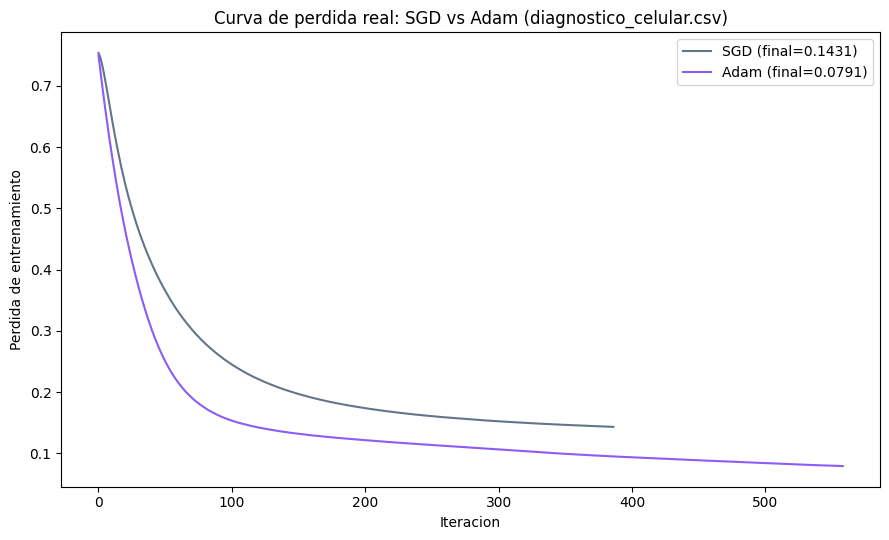

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mlp_sgd.loss_curve_, label=f"SGD (final={mlp_sgd.loss_curve_[-1]:.4f})", color="#64748b")
ax.plot(mlp_adam.loss_curve_, label=f"Adam (final={mlp_adam.loss_curve_[-1]:.4f})", color="#8b5cf6")
ax.set_xlabel("Iteracion")
ax.set_ylabel("Perdida de entrenamiento")
ax.set_title("Curva de perdida real: SGD vs Adam (diagnostico_celular.csv)")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la curva de Adam (violeta) desciende de forma marcadamente más rápida en las primeras iteraciones y llega a un nivel de pérdida más bajo que SGD (gris) en prácticamente todo el entrenamiento — la ventaja práctica de las tasas de aprendizaje adaptativas por parámetro descrita arriba, confirmada aquí con datos reales, no supuesta de antemano. SGD desciende de forma más gradual y termina en una meseta más alta. Esta es precisamente la razón por la que Adam es, hoy en día, el optimizador por defecto en la gran mayoría de librerías de redes neuronales (incluyendo `MLPClassifier`, donde `solver="adam"` es el valor por defecto).

---
## 5. Regularización L2: el Hiperparámetro `alpha` ⚖️

`MLPClassifier` permite penalizar pesos grandes agregando un término a la función de pérdida que se está minimizando:

$$L_{\text{total}} = L_{\text{original}} + \alpha \sum_{\text{todos los pesos}} w^2$$

Este término adicional —**regularización L2** (también llamada *weight decay*)— penaliza la **magnitud** de los pesos: entre dos configuraciones de pesos que ajustan igual de bien los datos de entrenamiento, el optimizador prefiere la que tiene pesos más pequeños. Pesos grandes suelen ser la firma de una red que está memorizando detalles específicos (incluido el ruido) del conjunto de entrenamiento; al penalizarlos, la función que aprende la red tiende a ser más "suave" y generaliza mejor. El hiperparámetro `alpha` controla la fuerza de esa penalización: `alpha` muy bajo apenas restringe los pesos (riesgo de sobreajuste), `alpha` muy alto fuerza los pesos hacia cero con tanta fuerza que la red pierde capacidad de ajustar incluso los patrones reales (riesgo de subajuste) — el mismo balance sesgo-varianza que jugaba el hiperparámetro $C$ de SVM en el Cuaderno 00, aunque aquí actúa en dirección opuesta (`alpha` grande = modelo más simple, mientras que $C$ grande = modelo más complejo).

In [6]:
alphas = np.logspace(-4, 2, 13)
train_accs, test_accs = [], []

for a in alphas:
    modelo = MLPClassifier(hidden_layer_sizes=(32, 16), alpha=a, max_iter=1000, random_state=42)
    modelo.fit(X_tr_s, y_tr)
    train_accs.append(modelo.score(X_tr_s, y_tr))
    test_accs.append(modelo.score(X_te_s, y_te))
    print(f"alpha={a:9.5g}   train={train_accs[-1]:.4f}   test={test_accs[-1]:.4f}   iteraciones={modelo.n_iter_}")

mejor_idx = int(np.argmax(test_accs))
print(f"\nMejor alpha segun exactitud de prueba: {alphas[mejor_idx]:.5g}  (exactitud={test_accs[mejor_idx]:.4f})")

alpha=   0.0001   train=0.9950   test=0.9591   iteraciones=949
alpha=0.00031623   train=0.9874   test=0.9708   iteraciones=773
alpha=    0.001   train=0.9874   test=0.9708   iteraciones=772
alpha=0.0031623   train=0.9899   test=0.9708   iteraciones=842
alpha=     0.01   train=0.9925   test=0.9649   iteraciones=937
alpha= 0.031623   train=0.9874   test=0.9649   iteraciones=715
alpha=      0.1   train=0.9849   test=0.9649   iteraciones=724
alpha=  0.31623   train=0.9749   test=0.9649   iteraciones=507
alpha=        1   train=0.9673   test=0.9474   iteraciones=506
alpha=   3.1623   train=0.9548   test=0.9357   iteraciones=454
alpha=       10   train=0.9347   test=0.9298   iteraciones=431
alpha=   31.623   train=0.9221   test=0.9298   iteraciones=451
alpha=      100   train=0.6281   test=0.6257   iteraciones=456

Mejor alpha segun exactitud de prueba: 0.00031623  (exactitud=0.9708)


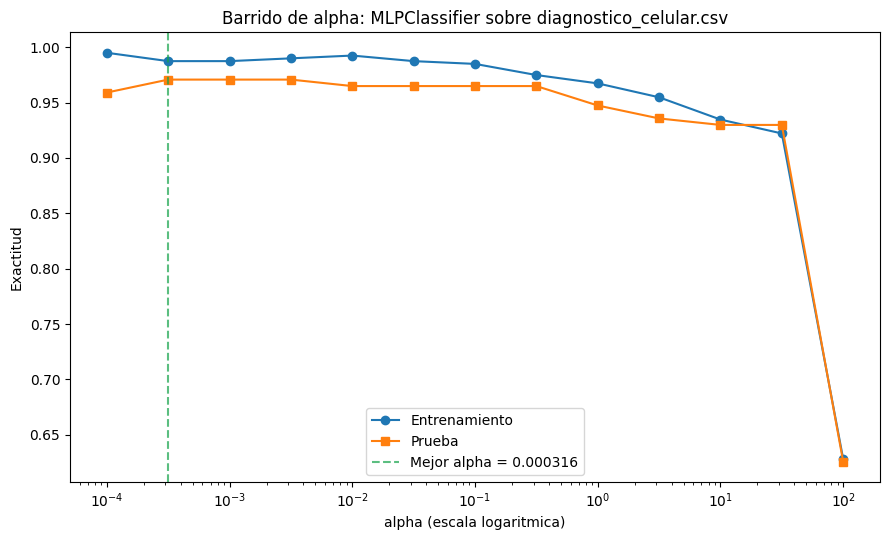

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(alphas, train_accs, marker="o", label="Entrenamiento")
ax.plot(alphas, test_accs, marker="s", label="Prueba")
ax.axvline(alphas[mejor_idx], color="#16a34a", linestyle="--", alpha=0.7,
           label=f"Mejor alpha = {alphas[mejor_idx]:.3g}")
ax.set_xscale("log")
ax.set_xlabel("alpha (escala logaritmica)")
ax.set_ylabel("Exactitud")
ax.set_title("Barrido de alpha: MLPClassifier sobre diagnostico_celular.csv")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** la curva muestra el patrón clásico de sobreajuste-subajuste. Con `alpha=0.0001` (la regularización más débil del barrido), la exactitud de entrenamiento es la más alta de todo el barrido (**99.50%**) pero la de prueba es notablemente menor (**95.91%**) — la brecha de casi 4 puntos entre ambas es la firma del **sobreajuste**: el modelo se ajusta a particularidades del conjunto de entrenamiento que no generalizan. La exactitud de prueba mejora y se estabiliza en una meseta entre `alpha≈0.0003` y `alpha≈0.003`, alcanzando su máximo (**97.08%**) en `alpha≈0.00032`, con una brecha entrenamiento-prueba mucho más pequeña. Para `alpha` grandes (≥10), tanto la exactitud de entrenamiento como la de prueba **caen juntas** —en `alpha=100` ambas se desploman a alrededor de **62.6%**— la firma del **subajuste**: la penalización es tan fuerte que fuerza casi todos los pesos hacia cero, y la red pierde la capacidad de representar incluso los patrones reales de los datos.

---
## 6. Parada Temprana (*Early Stopping*) ⏱️

`early_stopping=True` cambia el criterio para decidir cuándo detener el entrenamiento: en vez de entrenar siempre hasta `max_iter` (o hasta que la pérdida de entrenamiento deje de mejorar), `MLPClassifier` aparta automáticamente una fracción de los datos de entrenamiento como **conjunto de validación** (`validation_fraction`) y detiene el entrenamiento en cuanto la exactitud sobre ese conjunto deja de mejorar durante `n_iter_no_change` iteraciones consecutivas. La idea: el error de entrenamiento casi siempre puede seguir bajando (la red sigue memorizando), pero en algún punto eso deja de traducirse en mejor desempeño sobre datos nuevos — parar en ese punto evita seguir sobreajustando, sin tener que adivinar de antemano cuántas iteraciones son "las correctas".

El parámetro `n_iter_no_change` funciona como la **paciencia** del criterio: cuántas iteraciones sin mejora se toleran antes de rendirse. Una paciencia muy corta puede detener el entrenamiento **antes** de que el modelo haya tenido oportunidad real de aprender (si el desempeño de validación se estanca temporalmente al principio, algo común mientras los pesos todavía están lejos de ser útiles); una paciencia más generosa da más margen, a costa de más iteraciones de cómputo. La siguiente celda compara tres configuraciones reales sobre los mismos datos.

In [8]:
with warnings.catch_warnings(record=True) as adv_no_es:
    warnings.simplefilter("always")
    mlp_sin_es = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42,
                                early_stopping=False)
    mlp_sin_es.fit(X_tr_s, y_tr)

mlp_es_10 = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42,
                           early_stopping=True, validation_fraction=0.15, n_iter_no_change=10)
mlp_es_10.fit(X_tr_s, y_tr)

mlp_es_20 = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42,
                           early_stopping=True, validation_fraction=0.15, n_iter_no_change=20)
mlp_es_20.fit(X_tr_s, y_tr)

print("Advertencias (sin early stopping):", [str(w.message) for w in adv_no_es])
print()
resultados = [
    ("Sin early stopping",              mlp_sin_es),
    ("Early stopping, paciencia=10",    mlp_es_10),
    ("Early stopping, paciencia=20",    mlp_es_20),
]
for nombre, modelo in resultados:
    print(f"{nombre:32s} -> iteraciones: {modelo.n_iter_:4d}   "
          f"train: {modelo.score(X_tr_s, y_tr):.4f}   test: {modelo.score(X_te_s, y_te):.4f}")

Advertencias (sin early stopping): []

Sin early stopping               -> iteraciones:  559   train: 0.9698   test: 0.9591
Early stopping, paciencia=10     -> iteraciones:   36   train: 0.8819   test: 0.8246
Early stopping, paciencia=20     -> iteraciones:   76   train: 0.9447   test: 0.9240


**Lectura:** sin parada temprana, el modelo entrena **559** iteraciones (convergencia natural, misma cifra que Adam en la Sección 4 — es literalmente el mismo modelo) y llega a **95.91%** de exactitud de prueba. Con paciencia corta (`n_iter_no_change=10`), el entrenamiento se detiene mucho antes —apenas **36** iteraciones— y la exactitud de prueba cae a **82.46%**: la validación se estancó de forma temporal muy al principio del entrenamiento (mientras la red apenas empezaba a aprender) y el criterio, con tan poca paciencia, se rindió prematuramente — un subajuste inducido por detener el entrenamiento demasiado pronto. Con paciencia más generosa (`n_iter_no_change=20`), el entrenamiento continúa hasta **76** iteraciones y la exactitud de prueba sube a **92.40%**, recuperando buena parte del desempeño sin llegar a las 559 iteraciones completas. La lección práctica es clara: la parada temprana **sí** puede ahorrar cómputo y prevenir sobreajuste, pero el valor de `n_iter_no_change` importa tanto como la decisión de activarla — demasiado poca paciencia detiene el aprendizaje antes de que haya despegado.

---
## 7. Ejercicio Práctico Guiado: Combinando Todo ✍️

**Contexto:** este cuaderno mostró tres técnicas por separado: el optimizador Adam (Sección 4), la regularización L2 con el mejor `alpha` encontrado (Sección 5, `alpha≈0.00032`, exactitud de prueba 0.9708), y la parada temprana (Sección 6). Este ejercicio las combina en un solo modelo.

**Tu misión:**
1. Entrena `MLPClassifier(hidden_layer_sizes=(16, 8), solver="adam", alpha=0.00032, max_iter=1000, random_state=42, early_stopping=True, validation_fraction=0.15, n_iter_no_change=20)` sobre `X_tr_s`, `y_tr`.
2. Calcula su exactitud en entrenamiento y en prueba, y el número de iteraciones (`.n_iter_`).
3. Compara los tres números contra: (a) Adam sin regularización extra ni parada temprana (Sección 4: test 0.9591, 559 iteraciones), (b) el mejor `alpha` solo, sin parada temprana (Sección 5: test 0.9708), y (c) parada temprana sola con paciencia=20 (Sección 6: test 0.9240, 76 iteraciones).
4. Escribe como comentario tu conclusión: ¿combinar las tres técnicas mejora sobre usarlas por separado en este caso?

In [9]:
### TU CODIGO AQUI ###

# 1. Entrena el modelo combinado
mlp_combinado = None

# 2. Exactitud en entrenamiento, en prueba, e iteraciones
acc_train_combinado = None
acc_test_combinado = None

# 3. Compara contra los resultados de las Secciones 4, 5 y 6

# 4. Escribe tu conclusion aqui como comentario

<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
mlp_combinado = MLPClassifier(hidden_layer_sizes=(16, 8), solver="adam", alpha=0.00032,
                               max_iter=1000, random_state=42, early_stopping=True,
                               validation_fraction=0.15, n_iter_no_change=20)
mlp_combinado.fit(X_tr_s, y_tr)

acc_train_combinado = mlp_combinado.score(X_tr_s, y_tr)
acc_test_combinado = mlp_combinado.score(X_te_s, y_te)

print(f"Combinado -> iteraciones: {mlp_combinado.n_iter_}   "
      f"train: {acc_train_combinado:.4f}   test: {acc_test_combinado:.4f}")
print(f"Adam solo (Sec. 4)        -> iteraciones: 559   test: 0.9591")
print(f"Mejor alpha solo (Sec. 5) -> test: 0.9708")
print(f"Early stopping p=20 (Sec. 6) -> iteraciones: 76   test: 0.9240")
```

Resultado real:

```
Combinado -> iteraciones: 76   train: 0.9447   test: 0.9240
Adam solo (Sec. 4)        -> iteraciones: 559   test: 0.9591
Mejor alpha solo (Sec. 5) -> test: 0.9708
Early stopping p=20 (Sec. 6) -> iteraciones: 76   test: 0.9240
```

**Conclusión:** combinar las tres técnicas en este caso concreto **no supera** a la mejor técnica individual (regularización L2 sola, 97.08%) — de hecho, el resultado combinado (92.40%) coincide exactamente con el de parada temprana sola con la misma paciencia, porque aquí es la parada temprana la que domina el resultado: el entrenamiento se detiene en la iteración 76 antes de que la regularización L2, con un `alpha` tan pequeño, tenga oportunidad de marcar una diferencia notable frente a no tenerla. La lección no es que combinar técnicas de regularización sea mala idea en general, sino que **su interacción importa**: aquí, la parada temprana ya está actuando como el freno dominante, así que agregar L2 encima apenas cambia el resultado. En la práctica, esto sugiere ajustar la paciencia de la parada temprana y la fuerza de `alpha` **juntas** (por ejemplo, con una búsqueda de hiperparámetros), no asumir que técnicas de regularización distintas se suman linealmente en su efecto.

</details>

---
## 8. Resumen Ejecutivo 🎓

Este cuaderno respondió la pregunta que dejó abierta el Cuaderno 02 —¿cómo aprende una red los pesos que usa?— cubriendo, siempre con datos reales de `diagnostico_celular.csv`, las piezas centrales del entrenamiento:

- **Retropropagación es la regla de la cadena aplicada capa por capa:** el error se mide en la salida y se propaga hacia atrás para calcular el gradiente de la pérdida respecto a cada peso. Un ejemplo mínimo de un solo peso mostró el cálculo explícito: $\frac{\partial L}{\partial w}=-0.1058$ llevó a una actualización que bajó la pérdida de 0.0362 a 0.0348 en un solo paso.
- **Adam converge más rápido y más profundo que SGD plano** gracias a tasas de aprendizaje adaptativas por parámetro: sobre los mismos datos, Adam alcanzó una pérdida final de 0.0791 y 95.91% de exactitud de prueba, frente a 0.1431 y 93.57% de SGD — confirmado con las curvas de pérdida reales, no asumido de antemano.
- **La regularización L2 (`alpha`) penaliza pesos grandes:** el barrido real mostró sobreajuste claro en `alpha` muy bajo (brecha train-test de casi 4 puntos en `alpha=0.0001`) y subajuste severo en `alpha` muy alto (62.6% de exactitud, tanto en train como en test, en `alpha=100`), con el óptimo (97.08% de prueba) en una meseta intermedia alrededor de `alpha≈0.0003`.
- **La parada temprana ahorra cómputo y previene sobreajuste, pero es sensible a su paciencia (`n_iter_no_change`):** con paciencia=10 el entrenamiento se detuvo en solo 36 iteraciones y la exactitud de prueba cayó a 82.46%; con paciencia=20, llegó a 76 iteraciones y 92.40% — ninguna alcanzó las 559 iteraciones (95.91%) del entrenamiento sin restricciones, ilustrando el costo real de detenerse demasiado pronto.
- **Combinar técnicas no garantiza sumar sus beneficios:** el modelo con Adam + L2 + parada temprana simultáneos (92.40%) quedó por debajo del mejor `alpha` usado solo (97.08%) — su interacción, no solo su presencia individual, determina el resultado final.

**Cierre del bloque de redes neuronales del Módulo 06:** los Cuadernos 02 y 03 cubrieron, de principio a fin, cómo una red neuronal calcula una predicción (propagación hacia adelante) y cómo aprende los pesos que usa para calcularla (retropropagación, optimizadores, regularización). El Cuaderno **04 — Comparativa: SVM vs. Redes Neuronales en Minería de Datos** — cierra el módulo completo evaluando, con evidencia empírica sobre los mismos datasets usados en los Cuadernos 00, 01, 02 y 03, cuándo conviene una Máquina de Soporte Vectorial y cuándo conviene una red neuronal.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | SVM y Redes Neuronales</i>
  </p>
</div>